Loading Block A objects...
  Training set: 26,074 rows
  Test set    : 6,519 rows
  Class distribution before SMOTE:
    No dropout (0): 17,949  (68.8%)
    Dropout    (1): 8,125  (31.2%)

B1: Applying SMOTE to training data...
  Class distribution AFTER SMOTE:
    No dropout (0): 17,949  (50.0%)
    Dropout    (1): 17,949  (50.0%)
  Total training rows after SMOTE: 35,898  (was 26,074)

B2: Visualising class balance...


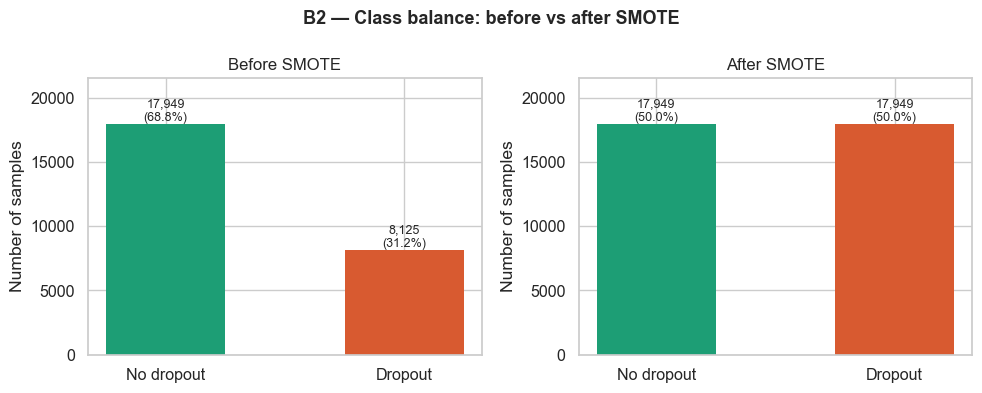

  Saved → ./outputs/phase4/block_b/B2_class_balance.png

B3: SMOTE impact — logistic regression with vs without SMOTE...

  Metric            Without SMOTE      With SMOTE
  ─────────────── ─────────────── ───────────────
  AUC                       0.880           0.879  ▼ -0.001
  PRECISION                 0.710           0.648  ▼ -0.061
  RECALL                    0.687           0.830  ▲ +0.142
  F1                        0.698           0.728  ▲ +0.030

B4: Finding optimal classification threshold...
  Optimal threshold (max F1 on training set): 0.377
  F1 at optimal threshold: 0.829
  (Default threshold = 0.50)



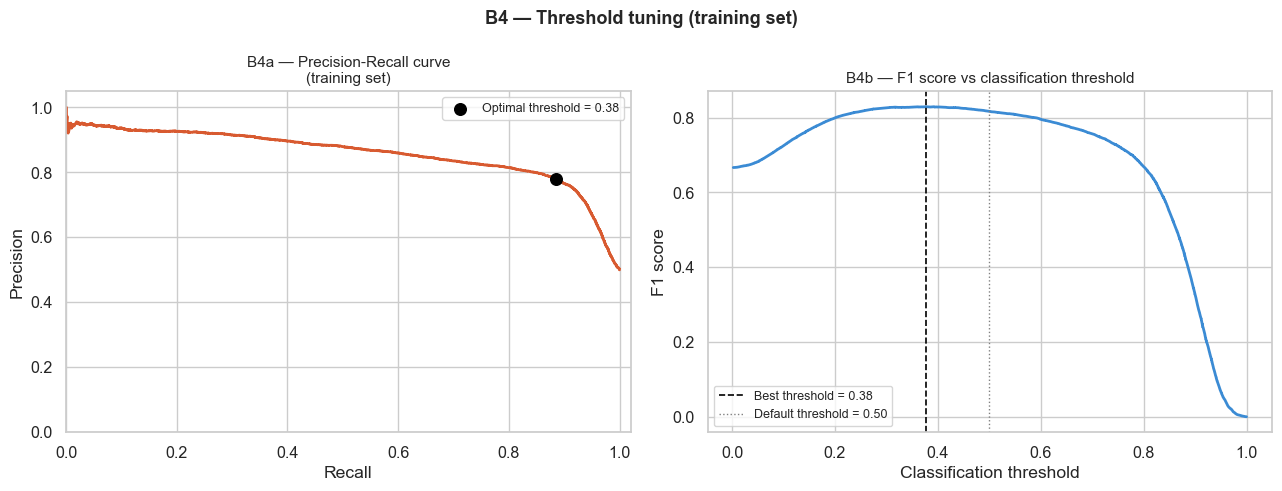

  Saved → ./outputs/phase4/block_b/B4_threshold_tuning.png

B5: Saving SMOTE outputs...
  Saved → ./outputs/phase4/block_b/block_b_objects.pkl

BLOCK B COMPLETE — SMOTE Class Imbalance Handling

  Original training distribution:
    No dropout : 17,949  (68.8%)
    Dropout    : 8,125  (31.2%)

  After SMOTE:
    No dropout : 17,949  (50.0%)
    Dropout    : 17,949  (50.0%)
    Total rows : 35,898

  SMOTE impact on logistic regression recall:
    Without SMOTE: 0.687
    With SMOTE   : 0.830

  Optimal classification threshold: 0.377
  (Will be applied in Block D evaluation)

  ✅ Test set untouched — all SMOTE applied to training only

  Saved → ./outputs/phase4/block_b/block_b_objects.pkl

─────────────────────────────────────────────────────────
Next → Run phase4_block_c_model_training.py
─────────────────────────────────────────────────────────



In [3]:
"""
=============================================================
Phase 4 — Block B: Class Imbalance — SMOTE
=============================================================
Goal: Address the 30/70 dropout/non-dropout imbalance so models
      don't simply predict "no dropout" for everyone.

The problem:
  Our dataset has ~30% dropouts and ~70% non-dropouts.
  A naive model can achieve 70% accuracy by predicting
  "no dropout" for EVERY student — zero useful predictions.
  Precision and recall for the minority class (dropouts)
  would both be 0.

Two strategies we apply:
  1. SMOTE (Synthetic Minority Oversampling TEchnique)
       Creates synthetic dropout examples in the training set
       by interpolating between existing minority-class samples.
       APPLIED TO TRAINING DATA ONLY — test set stays real.

  2. class_weight='balanced' (used in Block C)
       Tells sklearn models to weight minority-class errors more
       heavily during training. A complement to SMOTE.

  3. Threshold tuning (explored here)
       Default classification threshold is 0.5. For dropout
       detection, we often want higher recall (catch more
       dropouts even at the cost of some false alarms).
       We identify the optimal threshold on the training set.

What SMOTE does NOT do:
  • It does NOT add real students to the dataset
  • It does NOT modify the test set (that would be cheating)
  • It does NOT guarantee better results — always evaluate on
    the untouched test set
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, f1_score
)

# ── Config ────────────────────────────────────────────────────
BLOCK_A_PATH = './outputs/phase4/block_a/'
OUTPUT_PATH  = './outputs/phase4/block_b/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load Block A objects ───────────────────────────────────────
print("Loading Block A objects...")
with open(os.path.join(BLOCK_A_PATH, 'block_a_objects.pkl'), 'rb') as f:
    a = pickle.load(f)

X_train = a['X_train']
X_test  = a['X_test']
y_train = a['y_train']
y_test  = a['y_test']
FEATURES     = a['feature_names']
RANDOM_STATE = a['RANDOM_STATE']

print(f"  Training set: {X_train.shape[0]:,} rows")
print(f"  Test set    : {X_test.shape[0]:,} rows")
print(f"  Class distribution before SMOTE:")
counter = Counter(y_train)
print(f"    No dropout (0): {counter[0]:,}  ({counter[0]/len(y_train)*100:.1f}%)")
print(f"    Dropout    (1): {counter[1]:,}  ({counter[1]/len(y_train)*100:.1f}%)\n")


# =============================================================
# B1: Apply SMOTE to training data
# =============================================================
# SMOTE works by:
#   1. For each minority-class sample, find its k nearest neighbours
#      (also minority-class) in feature space.
#   2. Randomly pick one neighbour.
#   3. Create a synthetic sample at a random point BETWEEN the
#      original sample and the chosen neighbour.
#
# This avoids simple duplication (which just overfits) and creates
# new, plausible feature combinations.
#
# CRITICAL: SMOTE is applied AFTER the train/test split and ONLY
# to the training set. Never apply SMOTE before splitting —
# that leaks synthetic test-set samples into training.

print("B1: Applying SMOTE to training data...")

smote = SMOTE(
    sampling_strategy='minority',   # oversample only the minority class
    k_neighbors=5,                  # use 5 nearest neighbours (default)
    random_state=RANDOM_STATE
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

counter_res = Counter(y_train_res)
print(f"  Class distribution AFTER SMOTE:")
print(f"    No dropout (0): {counter_res[0]:,}  ({counter_res[0]/len(y_train_res)*100:.1f}%)")
print(f"    Dropout    (1): {counter_res[1]:,}  ({counter_res[1]/len(y_train_res)*100:.1f}%)")
print(f"  Total training rows after SMOTE: {len(X_train_res):,}  "
      f"(was {len(X_train):,})\n")


# =============================================================
# B2: Visualise class balance before vs after
# =============================================================

print("B2: Visualising class balance...")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (counts, title) in zip(axes, [
    (Counter(y_train),     "Before SMOTE"),
    (Counter(y_train_res), "After SMOTE"),
]):
    labels = ['No dropout', 'Dropout']
    values = [counts[0], counts[1]]
    bar_colors = [COLORS['teal'], COLORS['coral']]
    bars = ax.bar(labels, values, color=bar_colors, edgecolor='none', width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 50,
                f"{val:,}\n({val/sum(values)*100:.1f}%)",
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Number of samples")
    ax.set_ylim(0, max(values) * 1.2)

plt.suptitle("B2 — Class balance: before vs after SMOTE",
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B2_class_balance.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B3: Quick comparison — with vs without SMOTE
# =============================================================
# Fit a simple logistic regression both ways to show the impact
# of SMOTE on recall for the dropout class.

print("B3: SMOTE impact — logistic regression with vs without SMOTE...")

results_compare = {}

for label, Xtr, ytr in [
    ('Without SMOTE', X_train,     y_train),
    ('With SMOTE',    X_train_res, y_train_res),
]:
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(Xtr, ytr)
    y_pred  = lr.predict(X_test)
    y_proba = lr.predict_proba(X_test)[:, 1]

    from sklearn.metrics import precision_score, recall_score
    results_compare[label] = {
        'auc':       roc_auc_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
    }

print(f"\n  {'Metric':<15} {'Without SMOTE':>15} {'With SMOTE':>15}")
print(f"  {'─'*15} {'─'*15} {'─'*15}")
for metric in ['auc', 'precision', 'recall', 'f1']:
    v_no  = results_compare['Without SMOTE'][metric]
    v_yes = results_compare['With SMOTE'][metric]
    delta = v_yes - v_no
    arrow = f"▲ +{delta:.3f}" if delta > 0 else f"▼ {delta:.3f}"
    print(f"  {metric.upper():<15} {v_no:>15.3f} {v_yes:>15.3f}  {arrow}")
print()


# =============================================================
# B4: Threshold tuning
# =============================================================
# The default decision threshold (0.5) maximises overall accuracy
# but is not ideal for dropout detection where we want high recall
# (catching as many real dropouts as possible).
#
# We find the threshold that maximises F1 on the training set,
# then apply it to the test set for evaluation in Block D.

print("B4: Finding optimal classification threshold...")

# Fit the SMOTE-balanced model
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_res, y_train_res)
y_proba_train = lr_smote.predict_proba(X_train_res)[:, 1]

# Compute precision-recall curve across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_res, y_proba_train)

# F1 = 2 × (precision × recall) / (precision + recall)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])   # last element has no matching threshold
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"  Optimal threshold (max F1 on training set): {best_thresh:.3f}")
print(f"  F1 at optimal threshold: {best_f1:.3f}")
print(f"  (Default threshold = 0.50)\n")

# Plot precision-recall curve with optimal threshold marked
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: precision-recall curve ─────────────────────────────
axes[0].plot(recalls[:-1], precisions[:-1], color=COLORS['coral'], linewidth=2)
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color='black', zorder=5, s=70,
                label=f'Optimal threshold = {best_thresh:.2f}')
axes[0].set_title("B4a — Precision-Recall curve\n(training set)", fontsize=11)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1.02)
axes[0].set_ylim(0, 1.05)

# ── Right: F1 vs threshold ────────────────────────────────────
axes[1].plot(thresholds, f1_scores[:-1], color=COLORS['blue'], linewidth=2)
axes[1].axvline(best_thresh, color='black', linestyle='--', linewidth=1.2,
                label=f'Best threshold = {best_thresh:.2f}')
axes[1].axvline(0.5, color='gray', linestyle=':', linewidth=1,
                label='Default threshold = 0.50')
axes[1].set_title("B4b — F1 score vs classification threshold", fontsize=11)
axes[1].set_xlabel("Classification threshold")
axes[1].set_ylabel("F1 score")
axes[1].legend(fontsize=9)

plt.suptitle("B4 — Threshold tuning (training set)", fontsize=13,
             fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B4_threshold_tuning.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B5: Save SMOTE outputs for Block C
# =============================================================

print("B5: Saving SMOTE outputs...")

smote_objects = {
    'X_train_res':  X_train_res,
    'y_train_res':  y_train_res,
    'X_test':       X_test,
    'y_test':       y_test,
    'best_threshold': best_thresh,
    'feature_names':  FEATURES,
    'RANDOM_STATE':   RANDOM_STATE,
}

save_path = os.path.join(OUTPUT_PATH, 'block_b_objects.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(smote_objects, f)

print(f"  Saved → {save_path}\n")


# =============================================================
# BLOCK B SUMMARY
# =============================================================
print("=" * 60)
print("BLOCK B COMPLETE — SMOTE Class Imbalance Handling")
print("=" * 60)
print(f"""
  Original training distribution:
    No dropout : {counter[0]:,}  ({counter[0]/len(y_train)*100:.1f}%)
    Dropout    : {counter[1]:,}  ({counter[1]/len(y_train)*100:.1f}%)

  After SMOTE:
    No dropout : {counter_res[0]:,}  ({counter_res[0]/len(y_train_res)*100:.1f}%)
    Dropout    : {counter_res[1]:,}  ({counter_res[1]/len(y_train_res)*100:.1f}%)
    Total rows : {len(X_train_res):,}

  SMOTE impact on logistic regression recall:
    Without SMOTE: {results_compare['Without SMOTE']['recall']:.3f}
    With SMOTE   : {results_compare['With SMOTE']['recall']:.3f}

  Optimal classification threshold: {best_thresh:.3f}
  (Will be applied in Block D evaluation)

  ✅ Test set untouched — all SMOTE applied to training only

  Saved → {save_path}

─────────────────────────────────────────────────────────
Next → Run phase4_block_c_model_training.py
─────────────────────────────────────────────────────────
""")